# STEP 1: Loading Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## STEP 2: Load the data

In [122]:
# Import the features and the labels
features = pd.read_csv("../data/raw/features.csv")
labels = pd.read_csv("../data/raw/labels.csv")

print(f"Features: {display(features.head())}")
print(f"Labels: {display(labels.head())}")

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


Features: None


,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


Labels: None


## STEP 3: Pre-Cleaning EDA

In [123]:
# Check shape, columns, info
def check_df(df):
    print("Features dataset Shape: ", df.shape)
    print("Labels dataset Shape: ", labels.shape)
    print("Columns:", df.columns.tolist())
    print("Info:")
    print(df.info())


check_df(features)

Features dataset Shape:  (59400, 40)
Labels dataset Shape:  (59400, 2)
Columns: ['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'wpt_name', 'num_private', 'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'construction_year', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group']
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float

In [124]:
# convert the date_recorded and construction_year column into a datetime feature
features['date_recorded'] = pd.to_datetime(features['date_recorded'], errors='coerce')
features['construction_year'] = pd.to_datetime(features['construction_year'], format='%Y', errors='coerce')

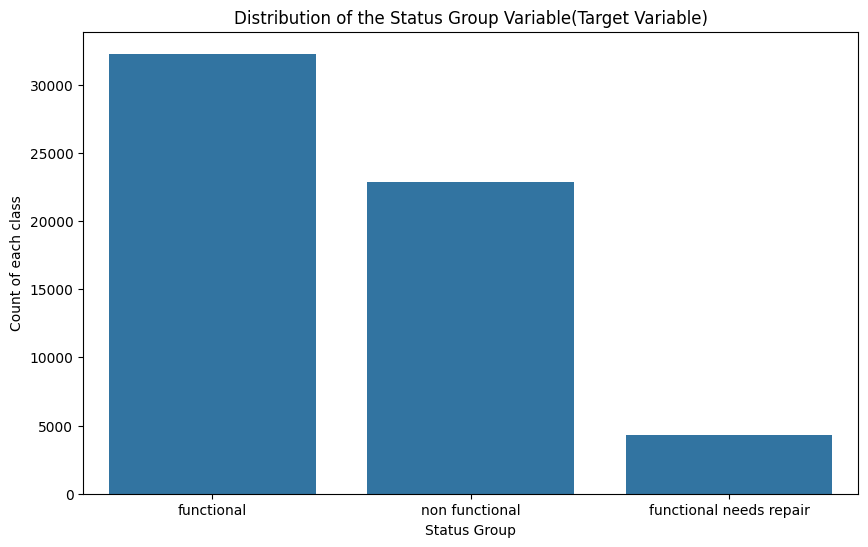

In [125]:
# PLot the distribution of the target variable
plt.figure(figsize=(10, 6))
sns.countplot(x=labels['status_group'], data=labels)
plt.title('Distribution of the Status Group Variable(Target Variable)')
plt.xlabel('Status Group')
plt.ylabel('Count of each class')
plt.show()

In [126]:
# Merge the target column and the features dataframe
data_df = pd.merge(features, labels, on = 'id', how = 'inner')

In [127]:
data_df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999-01-01,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010-01-01,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009-01-01,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986-01-01,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,NaT,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


Check for duplicates

In [128]:
print("Duplicates in the data_df are:", data_df.duplicated().sum())

Duplicates in the data_df are: 0


### Check for summary statistics and the missing values in the data_df

In [130]:
def basic_info(df):
    print("Summary statistics of the numerical features:")
    print(display(df.describe().T))
    print("\nSummary statistics of the categorical features:")
    print(display(df.describe(include=['object']).T))
    print("\nMissing values in the dataset:")
    print(df.isnull().sum())

basic_info(data_df)

Summary statistics of the numerical features:


,count,mean,min,25%,50%,75%,max,std
id,59400.0,37115.131768,0.0,18519.75,37061.5,55656.5,74247.0,21453.128371
amount_tsh,59400.0,317.650385,0.0,0.0,0.0,20.0,350000.0,2997.574558
date_recorded,59400,2012-03-29 09:11:33.818181888,2002-10-14 00:00:00,2011-04-01 00:00:00,2012-10-10 00:00:00,2013-02-09 00:00:00,2013-12-03 00:00:00,NaN
gps_height,59400.0,668.297239,-90.0,0.0,369.0,1319.25,2770.0,693.11635
longitude,59400.0,34.077427,0.0,33.090347,34.908743,37.178387,40.345193,6.567432
latitude,59400.0,-5.706033,-11.64944,-8.540621,-5.021597,-3.326156,-0.0,2.946019
num_private,59400.0,0.474141,0.0,0.0,0.0,0.0,1776.0,12.23623
region_code,59400.0,15.297003,1.0,5.0,12.0,17.0,99.0,17.587406
district_code,59400.0,5.629747,0.0,2.0,3.0,5.0,80.0,9.633649
population,59400.0,179.909983,0.0,0.0,25.0,215.0,30500.0,471.482176


None

Summary statistics of the categorical features:


,count,unique,top,freq
funder,55763,1896,Government Of Tanzania,9084
installer,55745,2145,DWE,17402
wpt_name,59398,37399,none,3563
basin,59400,9,Lake Victoria,10248
subvillage,59029,19287,Madukani,508
region,59400,21,Iringa,5294
lga,59400,125,Njombe,2503
ward,59400,2092,Igosi,307
public_meeting,56066,2,True,51011
recorded_by,59400,1,GeoData Consultants Ltd,59400


None

Missing values in the dataset:
id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year        20709
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
wa

**Dealing with nulls**
- Drop the nulls - if your nulls exceed 40% you drop the column - if your null are below 5%, you can either drop the rows or fill the rows
- Fill the nulls - if the column has less then 40% nulls
  - Filling nulls is based distribution, if data normally distributed fill it with the mean or median
  - For In a case of skewness use the median


### Check for different categories in the categorical features  

In [132]:
categorical_features = data_df.select_dtypes(include=['object']).columns
print("Categorical features in the dataset are:", categorical_features)

for column in categorical_features:
    print(f"Unique values in '{column}':")
    print(data_df[column].value_counts().to_dict())

Categorical features in the dataset are: Index(['funder', 'installer', 'wpt_name', 'basin', 'subvillage', 'region',
       'lga', 'ward', 'public_meeting', 'recorded_by', 'scheme_management',
       'scheme_name', 'permit', 'extraction_type', 'extraction_type_group',
       'extraction_type_class', 'management', 'management_group', 'payment',
       'payment_type', 'water_quality', 'quality_group', 'quantity',
       'quantity_group', 'source', 'source_type', 'source_class',
       'waterpoint_type', 'waterpoint_type_group', 'status_group'],
      dtype='object')
Unique values in 'funder':
{'Government Of Tanzania': 9084, 'Danida': 3114, 'Hesawa': 2202, 'Rwssp': 1374, 'World Bank': 1349, 'Kkkt': 1287, 'World Vision': 1246, 'Unicef': 1057, 'Tasaf': 877, 'District Council': 843, 'Dhv': 829, 'Private Individual': 826, 'Dwsp': 811, '0': 777, 'Norad': 765, 'Germany Republi': 610, 'Tcrs': 602, 'Ministry Of Water': 590, 'Water': 583, 'Dwe': 484, 'Netherlands': 470, 'Hifab': 450, 'Adb': 448, '

### Numerical Features check

In [133]:
numerical_features = data_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

numerical_features.remove('id')
numerical_features.remove('longitude')
numerical_features.remove('latitude')
numerical_features.remove('region_code')
numerical_features.remove('district_code')
numerical_features.remove('num_private')

print(numerical_features)


['amount_tsh', 'gps_height', 'population']


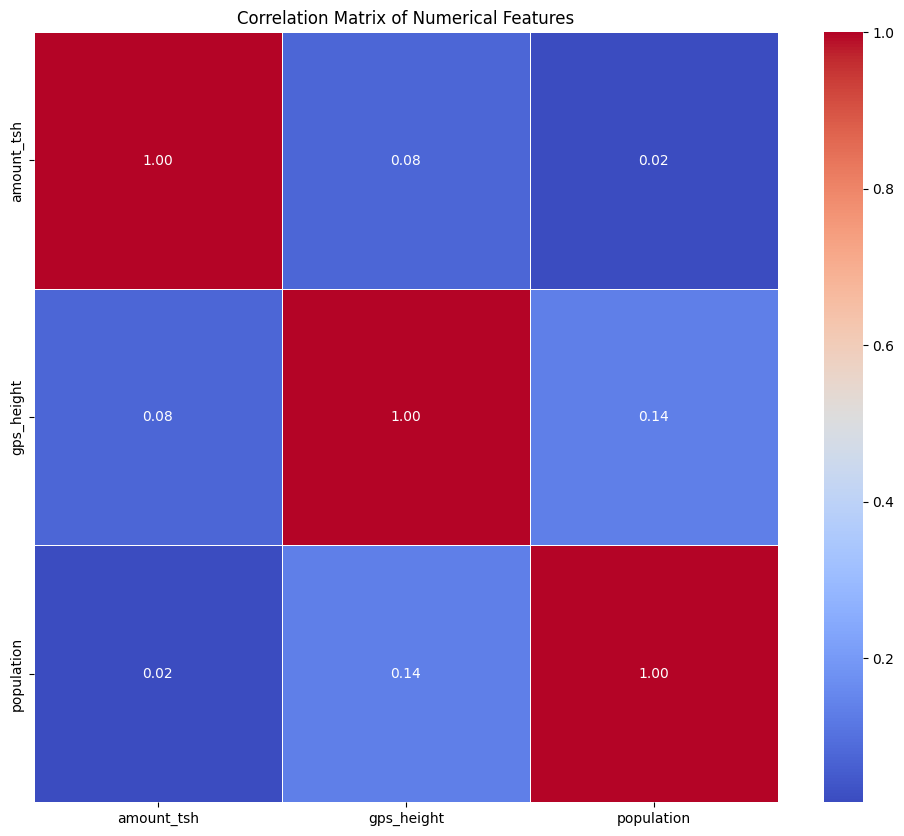

In [134]:
# Compute and lot the correlation matrix for the numerical features
correlation_matrix = data_df[numerical_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### STEP 4: Data Cleaning and Feature Engineering

In [135]:
# Creating a age column by calculating the difference between the date recorded and the construction year

data_df['age'] = data_df['date_recorded'].dt.year - data_df['construction_year'].dt.year

In [136]:
data_df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group,age
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999-01-01,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional,12.0
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010-01-01,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,3.0
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009-01-01,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional,4.0
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986-01-01,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional,27.0
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,NaT,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,NaN


In [137]:
# Add a month column from the date recorded column
data_df['month_recorded'] = data_df['date_recorded'].dt.month
data_df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group,age,month_recorded
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999-01-01,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional,12.0,3
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010-01-01,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,3.0,3
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009-01-01,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional,4.0,2
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986-01-01,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional,27.0,1
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,NaT,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,NaN,7


In [138]:
final_features = ['amount_tsh', 'gps_height', 'population', 'age', 'month_recorded', 'permit', 'waterpoint_type_group', 'source_class',
 'quantity', 'quality_group', 'payment_type', 'management_group', 'extraction_type_class', 'region', 'basin', 'status_group' ]

stripped_df = data_df[final_features]


print(f"Final stripped df shape{stripped_df.shape}")
display(stripped_df.head())

Final stripped df shape(59400, 16)


,amount_tsh,gps_height,population,age,month_recorded,permit,waterpoint_type_group,source_class,quantity,quality_group,payment_type,management_group,extraction_type_class,region,basin,status_group
0,6000.0,1390,109,12.0,3,False,communal standpipe,groundwater,enough,good,annually,user-group,gravity,Iringa,Lake Nyasa,functional
1,0.0,1399,280,3.0,3,True,communal standpipe,surface,insufficient,good,never pay,user-group,gravity,Mara,Lake Victoria,functional
2,25.0,686,250,4.0,2,True,communal standpipe,surface,enough,good,per bucket,user-group,gravity,Manyara,Pangani,functional
3,0.0,263,58,27.0,1,True,communal standpipe,groundwater,dry,good,never pay,user-group,submersible,Mtwara,Ruvuma / Southern Coast,non functional
4,0.0,0,0,NaN,7,True,communal standpipe,surface,seasonal,good,never pay,other,gravity,Kagera,Lake Victoria,functional


In [139]:
stripped_df.isnull().sum()

amount_tsh                   0
gps_height                   0
population                   0
age                      20709
month_recorded               0
permit                    3056
waterpoint_type_group        0
source_class                 0
quantity                     0
quality_group                0
payment_type                 0
management_group             0
extraction_type_class        0
region                       0
basin                        0
status_group                 0
dtype: int64

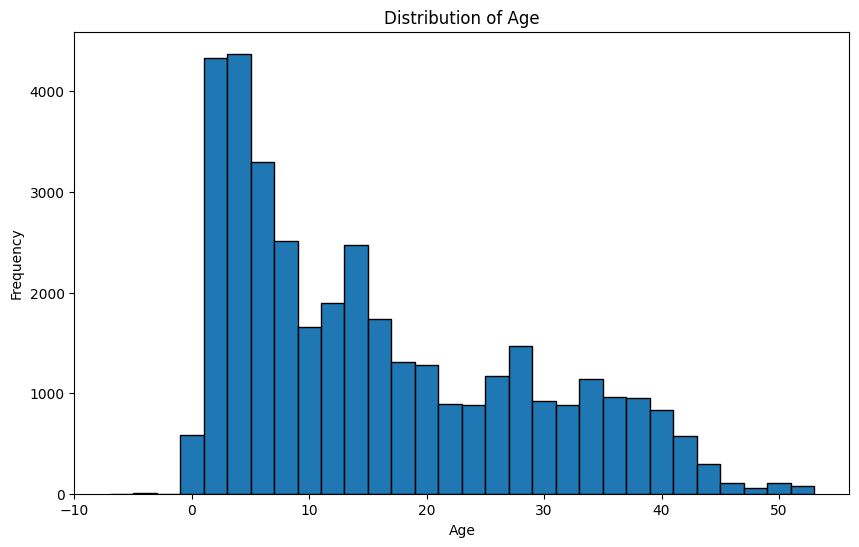

In [140]:
# Dropping the null values in the age column

columns_with_nulls = ['age', 'permit']
for column in columns_with_nulls:
    stripped_df = stripped_df.dropna(subset = [column])
    


# Plotting the distribution of the age column after dropping the null values
plt.figure(figsize=(10, 6))
plt.hist(stripped_df['age'], bins=30, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

In [141]:
stripped_df.isnull().sum()

amount_tsh               0
gps_height               0
population               0
age                      0
month_recorded           0
permit                   0
waterpoint_type_group    0
source_class             0
quantity                 0
quality_group            0
payment_type             0
management_group         0
extraction_type_class    0
region                   0
basin                    0
status_group             0
dtype: int64

### Recheck the unique entries in the categorical features

it will ensure that there is no discerepancies in the categorical due to incosistent formatting.

In [143]:
categorical_features_stripped = stripped_df.select_dtypes(include=['object']).columns
print("Categorical features in the stripped dataset are:", categorical_features_stripped)

for feature in categorical_features_stripped:
    print(f"Unique values in '{feature}':")
    print(stripped_df[feature].value_counts().to_dict())

Categorical features in the stripped dataset are: Index(['permit', 'waterpoint_type_group', 'source_class', 'quantity',
       'quality_group', 'payment_type', 'management_group',
       'extraction_type_class', 'region', 'basin', 'status_group'],
      dtype='object')
Unique values in 'permit':
{True: 26372, False: 10392}
Unique values in 'waterpoint_type_group':
{'communal standpipe': 24551, 'hand pump': 8252, 'other': 3539, 'improved spring': 363, 'cattle trough': 55, 'dam': 4}
Unique values in 'source_class':
{'groundwater': 27070, 'surface': 9490, 'unknown': 204}
Unique values in 'quantity':
{'enough': 21892, 'insufficient': 9614, 'dry': 3050, 'seasonal': 1779, 'unknown': 429}
Unique values in 'quality_group':
{'good': 32202, 'salty': 3307, 'unknown': 723, 'colored': 224, 'fluoride': 174, 'milky': 134}
Unique values in 'payment_type':
{'never pay': 13033, 'monthly': 7041, 'per bucket': 6745, 'unknown': 4542, 'annually': 2850, 'on failure': 2228, 'other': 325}
Unique values in 'man

In [144]:
# Standardise the entries 'Wami / Ruvu' and 'Ruvuma / Southern Coast' to 'Wami/Ruvu' and 'Ruvuma/Southern Coast' respectively in the basin column
stripped_df['basin'] = stripped_df['basin'].replace({'Wami / Ruvu': 'Wami/Ruvu', 'Ruvuma / Southern Coast': 'Ruvuma/Southern Coast'}) 

In [149]:
# Standardize and replace all spaces in categorical columns with underscores

for column in categorical_features_stripped:
    stripped_df[column] = (
        stripped_df[column]
        .astype("string")
        .str.replace(" ", "_")
    )

In [150]:
stripped_df.head()

,amount_tsh,gps_height,population,age,month_recorded,permit,waterpoint_type_group,source_class,quantity,quality_group,payment_type,management_group,extraction_type_class,region,basin,status_group
0,6000.0,1390,109,12.0,3,False,communal_standpipe,groundwater,enough,good,annually,user-group,gravity,Iringa,Lake_Nyasa,functional
1,0.0,1399,280,3.0,3,True,communal_standpipe,surface,insufficient,good,never_pay,user-group,gravity,Mara,Lake_Victoria,functional
2,25.0,686,250,4.0,2,True,communal_standpipe,surface,enough,good,per_bucket,user-group,gravity,Manyara,Pangani,functional
3,0.0,263,58,27.0,1,True,communal_standpipe,groundwater,dry,good,never_pay,user-group,submersible,Mtwara,Ruvuma/Southern_Coast,non_functional
5,20.0,0,1,2.0,3,True,communal_standpipe,unknown,enough,salty,per_bucket,user-group,submersible,Tanga,Pangani,functional


- How to deal with the remaining nulls *
- try to do post-cleaning eda(univariate analysis and visualization and bivariate visualization) *
- save the final clean dataset 


## FINAL STEP: Saving the cleaned dataset

In [151]:
stripped_df.to_csv("../data/processed/cleaned_data.csv", index=False)